#### Introduction
In this analysis, we examine the text of *The Adventures of Sherlock Holmes* by Arthur Conan Doyle.
The main goal is to uncover insights by exploring word frequencies, sentiment patterns, and recurring themes.
The steps involve preprocessing the text, analysing the data, and visualizing results.
    

#### Step 1: Data Loading and Initial Exploration
We begin by loading the dataset, which is a plain-text version of *The Adventures of Sherlock Holmes*.
Here, we preview the first 500 characters to get an idea of the structure and content of the text.
    

In [11]:
# Read the text file into a string variable
with open('sherlock.txt', 'r', encoding='utf-8') as file:
    text = file.read()

# Print the first 500 characters to preview the text in the file
print(text[:500])





                        THE ADVENTURES OF SHERLOCK HOLMES

                               Arthur Conan Doyle



                                Table of contents

               A Scandal in Bohemia
               The Red-Headed League
               A Case of Identity
               The Boscombe Valley Mystery
               The Five Orange Pips
               The Man with the Twisted Lip
               The Adventure of the Blue Carbuncle
               The Adventure of the Speckled Band
  


#### Step 2: Data Preprocessing
Text preprocessing is essential to ensure accurate analysis. In this step, we will perform some initial data preprocssing, splitting our text into sentences using the split function from the regular expression library. We will iterate over the first 10 sentences to check that this has worked as expected. 

In [12]:
# Import the regular expression module
import re

# Regex-based sentence splitting
sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?)\s', text)

# Print the first few sentences
for i, sentence in enumerate(sentences[1:11]):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: I have seldom heard him
     mention her under any other name.
Sentence 2: In his eyes she eclipses and
     predominates the whole of her sex.
Sentence 3: It was not that he felt any
     emotion akin to love for Irene Adler.
Sentence 4: All emotions, and that one
     particularly, were abhorrent to his cold, precise but admirably
     balanced mind.
Sentence 5: He was, I take it, the most perfect reasoning and
     observing machine that the world has seen, but as a lover he would
     have placed himself in a false position.
Sentence 6: He never spoke of the softer
     passions, save with a gibe and a sneer.
Sentence 7: They were admirable things
     for the observer--excellent for drawing the veil from men's motives
     and actions.
Sentence 8: But for the trained reasoner to admit such intrusions
     into his own delicate and finely adjusted temperament was to
     introduce a distracting factor which might throw a doubt upon all his
     mental results.
Sentence 


#### Step 3: Sentiment Analysis
Sentiment analysis helps us understand the emotional tone of the text.
Using the VADER SentimentIntensityAnalyzer, we compute sentiment scores for individual sentences and the entire text.
The scores include positive, neutral, negative, and compound values.
    

In [13]:
# Import the SentimentIntensityAnalyzer class
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Analyse sentiment for for first 10 sentences
analyzer = SentimentIntensityAnalyzer()
for i, sentence in enumerate(sentences[1:11]):
    sentiment = analyzer.polarity_scores(sentence)
    print(f"Sentence {i} Sentiment: {sentiment}")
    
# Display the overall sentiment of the text
sentiment = analyzer.polarity_scores(text)
print(f"Overall Sentiment: {sentiment}")
    

Sentence 0 Sentiment: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentence 1 Sentiment: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentence 2 Sentiment: {'neg': 0.0, 'neu': 0.756, 'pos': 0.244, 'compound': 0.6369}
Sentence 3 Sentiment: {'neg': 0.125, 'neu': 0.653, 'pos': 0.222, 'compound': 0.4697}
Sentence 4 Sentiment: {'neg': 0.0, 'neu': 0.765, 'pos': 0.235, 'compound': 0.827}
Sentence 5 Sentiment: {'neg': 0.0, 'neu': 0.61, 'pos': 0.39, 'compound': 0.7506}
Sentence 6 Sentiment: {'neg': 0.0, 'neu': 0.806, 'pos': 0.194, 'compound': 0.5574}
Sentence 7 Sentiment: {'neg': 0.166, 'neu': 0.739, 'pos': 0.096, 'compound': -0.5499}
Sentence 8 Sentiment: {'neg': 0.0, 'neu': 0.787, 'pos': 0.213, 'compound': 0.7567}
Sentence 9 Sentiment: {'neg': 0.232, 'neu': 0.768, 'pos': 0.0, 'compound': -0.7227}
Overall Sentiment: {'neg': 0.085, 'neu': 0.813, 'pos': 0.103, 'compound': 1.0}


#### Step 4: Visualise sentiment for the text in a line plot
* We've included a regression trend line in our plot to plot the trend

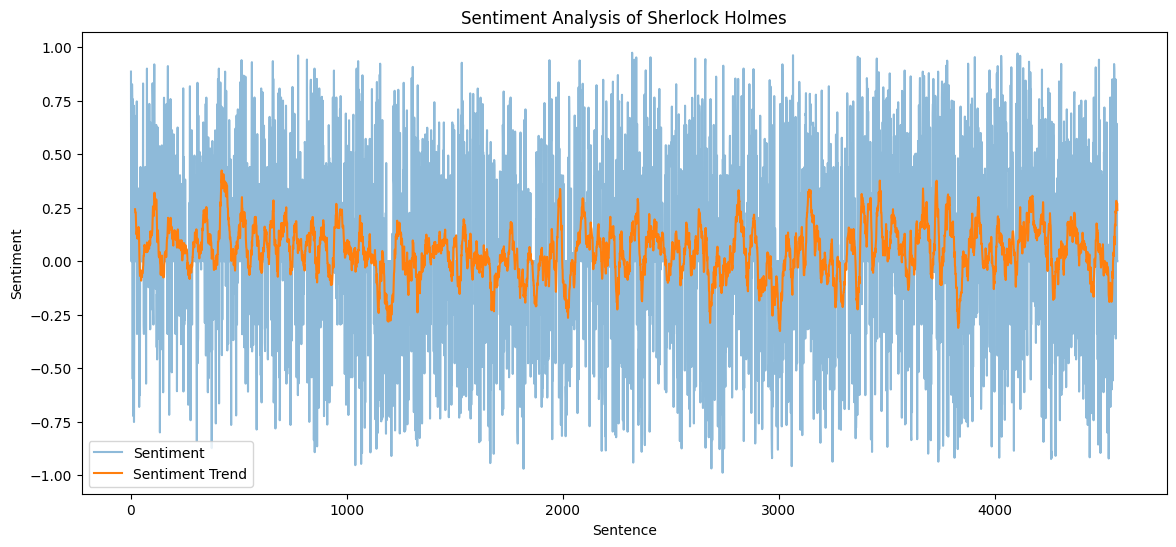

In [14]:
# Visulaise the sentiment scores
import matplotlib.pyplot as plt
import pandas as pd

# Get the sentiment scores for each sentence
sentiments = [analyzer.polarity_scores(sentence)['compound'] for sentence in sentences]

# Plot the sentiment scores with a regressed trend line
plt.figure(figsize=(14,6))
plt.plot(sentiments, label='Sentiment', alpha=0.5)
plt.plot(pd.Series(sentiments).rolling(20).mean(), label='Sentiment Trend')
plt.title('Sentiment Analysis of Sherlock Holmes')
plt.xlabel('Sentence')
plt.ylabel('Sentiment')
plt.legend()

#### Step 5: Continue data pre-processing and cleaning
We clean the text by:
- Removing punctuation and numerical values.
- Converting text to lowercase.
- Filtering out common stopwords using a custom list.

This step helps us focus on meaningful words and phrases.

In [15]:
# Define a function to clean the text data
def clean_text(text):
    """
    Cleans the input text by removing punctuation, special characters, 
    numeric values, and converting to lowercase.
    
    Args:
        text (str): The raw input text.

    Returns:
        list: A list of cleaned, lowercase words.
    """
    # Ensure all quotation marks are normalised
    text = text.replace("“", '"').replace("”", '"').replace("‘", "'").replace("’", "'")
    
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation except underscore
    text = re.sub(r"\s+", " ", text)  # Remove extra whitespace
    text = re.sub(r"\d+", "", text)  # Remove numbers
    
    # Convert to lowercase and split into words
    words = text.lower().split()
    return words

# Clean the words in the text
clean_text(text)

['the',
 'adventures',
 'of',
 'sherlock',
 'holmes',
 'arthur',
 'conan',
 'doyle',
 'table',
 'of',
 'contents',
 'a',
 'scandal',
 'in',
 'bohemia',
 'the',
 'redheaded',
 'league',
 'a',
 'case',
 'of',
 'identity',
 'the',
 'boscombe',
 'valley',
 'mystery',
 'the',
 'five',
 'orange',
 'pips',
 'the',
 'man',
 'with',
 'the',
 'twisted',
 'lip',
 'the',
 'adventure',
 'of',
 'the',
 'blue',
 'carbuncle',
 'the',
 'adventure',
 'of',
 'the',
 'speckled',
 'band',
 'the',
 'adventure',
 'of',
 'the',
 'engineers',
 'thumb',
 'the',
 'adventure',
 'of',
 'the',
 'noble',
 'bachelor',
 'the',
 'adventure',
 'of',
 'the',
 'beryl',
 'coronet',
 'the',
 'adventure',
 'of',
 'the',
 'copper',
 'beeches',
 'a',
 'scandal',
 'in',
 'bohemia',
 'table',
 'of',
 'contents',
 'chapter',
 'chapter',
 'chapter',
 'chapter',
 'i',
 'to',
 'sherlock',
 'holmes',
 'she',
 'is',
 'always',
 'the',
 'woman',
 'i',
 'have',
 'seldom',
 'heard',
 'him',
 'mention',
 'her',
 'under',
 'any',
 'other',

#### Step 6: Word Frequency Analysis
Using the cleaned text, we calculate the frequency of each word using Python's `collections.Counter`.
This analysis identifies the most frequently occurring words, providing insights into the text's key themes.

In [16]:
# Import the Counter class from the collections module
from collections import Counter

# Split the text into words
words = text.split()

# Perform additional cleaning to remove any remaining quotation marks,
# parentheses or special characters
words = [word.strip('-"()') for word in words]
words = [word.strip("'") for word in words]

# Print total word count
word_count = Counter(words)
print("Total word count:", len(words))

# Define a function to get the combined stopwords (nltk with custom stopwords)
def get_combined_stopwords():
    """
    Combines nltk stopwords with custom-defined stopwords.
    
    Returns:
        set: A set of stopwords.
    """
    from nltk.corpus import stopwords
    common_stopwords = {'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you',
                        'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself',
                        'she', 'her', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their',
                        'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that',
                        'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
                        'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the',
                        'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by',
                        'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during',
                        'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out',
                        'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
                        'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few',
                        'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own',
                        'same', 'so', 'than', 'too', 'very','can', 'will', 'just', 'should', "i",
                        "could", "would", "upon", "said", "holmes", "mr", "one", "man"}
    nltk_stop_words = set(stopwords.words('english'))
    return nltk_stop_words.union(common_stopwords)

# Print the 10 most common words including stopwords
print("The 10 most common words in the text (with counts) are:")
print(word_count.most_common(10))
print("\n")

# Get the English stopwords
stop_words = get_combined_stopwords()

# Remove the stopwords from the text and re-count the words
words = [word for word in words if word.lower() not in stop_words]
word_count = Counter(words)
print("Total word count:", len(words))

# Print the 10 most common words (with their counts) excluding stopwords
print("The 10 most common words in the text, excluding stop words are:")
print(word_count.most_common(10))

Total word count: 104527
The 10 most common words in the text (with counts) are:
[('the', 5259), ('I', 2927), ('and', 2750), ('to', 2640), ('of', 2616), ('a', 2523), ('in', 1649), ('that', 1570), ('was', 1360), ('his', 1097)]


Total word count: 47457
The 10 most common words in the text, excluding stop words are:
[('Mr.', 274), ('little', 257), ('may', 187), ('see', 183), ('shall', 168), ('must', 159), ('it.', 150), ('came', 142), ('Holmes,', 141), ('know', 136)]


#### Step 7: Visualisation of Word Frequencies
To make the results of the word frequency analysis more engaging, we generate:
- A line chart for the top 20 most common words.
- A word cloud to visualise word significance across the text.

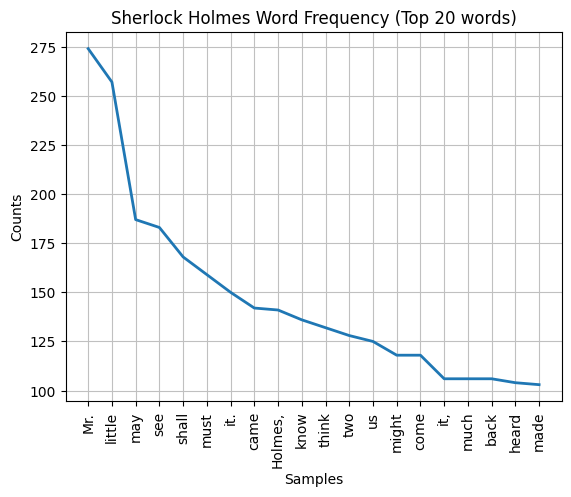

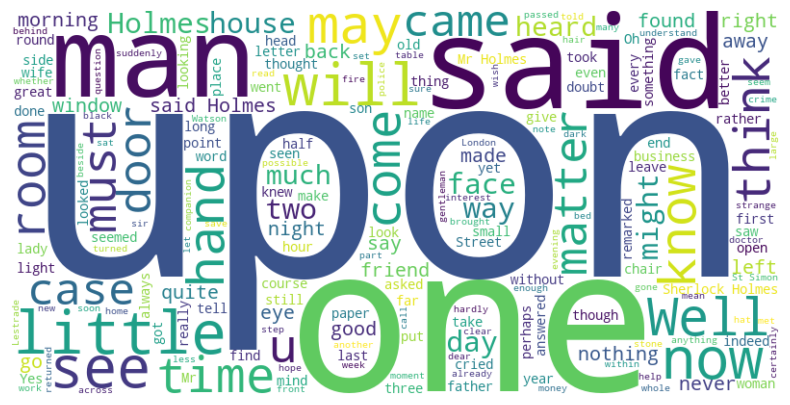

In [17]:
# Import Frequency Distribution function from the nltk library
from nltk.probability import FreqDist

# Use the FreqDist function to get the frequency distribution of the words
fd = FreqDist(words)

# Plot the data we have. 
import matplotlib.pyplot as plt

# Feed the plot all words as a parameter for our plot, setting cumulative as 'false'
fd.plot(20,cumulative=False, title="Sherlock Holmes Word Frequency (Top 20 words)")

# Import the WordCloud class
from wordcloud import WordCloud

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the generated image:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


#### Step 8: Thematic Analysis
Thematic analysis involves identifying recurring patterns and phrases in the text.
By extracting bigrams and trigrams, we uncover key relationships and topics.
For instance, frequent phrases like "Sherlock Holmes" and "Baker Street" reveal the focus of the narrative.

In [18]:
from nltk.util import ngrams
from collections import Counter

# Generate bigrams and trigrams from the words
bigrams = list(ngrams(words, 2))
trigrams = list(ngrams(words, 3))

# Count frequencies of bigrams and trigrams
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

# Get the most common bigrams and trigrams
top_bigrams = bigram_counts.most_common(10)
top_trigrams = trigram_counts.most_common(10)

# Format the results for inclusion in the report
formatted_bigrams = [(f"{w1} {w2}", count) for (w1, w2), count in top_bigrams]
formatted_trigrams = [(f"{w1} {w2} {w3}", count) for (w1, w2, w3), count in top_trigrams]

# Prepare results for the report
thematic_analysis_results = {
    "Top_Bigrams": formatted_bigrams,
    "Top_Trigrams": formatted_trigrams
}

thematic_analysis_results

{'Top_Bigrams': [('Mr. Holmes,', 44),
  ('Lord St.', 28),
  ('St. Simon', 22),
  ('Sherlock Holmes,', 17),
  ('Mr. Holmes.', 17),
  ('let us', 15),
  ('Neville St.', 15),
  ('Mr. Sherlock', 13),
  ('Mr. Hosmer', 13),
  ('St. Clair', 13)],
 'Top_Trigrams': [('Lord St. Simon', 16),
  ('Mr. Neville St.', 8),
  ('Lord St. Simon,', 8),
  ('Mr. Sherlock Holmes,', 7),
  ('Neville St. Clair', 6),
  ('Neville St. Clair,', 6),
  ('Colonel Lysander Stark', 6),
  ('Mr. Hosmer Angel.', 5),
  ('Mrs. St. Clair', 5),
  ('Sir George Burnwell', 5)]}

#### Step 9: Results Summary
Here, we compile and present the key findings from each step:
- Word frequencies highlight the most common words.

- Sentiment analysis reveals the emotional tone of the text.

- Thematic analysis uncovers recurring phrases and relationships.

- **Preprocessed Words Count**: 46638
- **Top 10 Words**:
  - `said` (486 occurrences)
  - `upon` (464 occurrences)
  - `holmes` (461 occurrences)
  - `one` (369 occurrences)
  - `man` (288 occurrences)
  - `mr` (274 occurrences)
  - `little` (269 occurrences)
  - `will` (262 occurrences)
  - `now` (231 occurrences)
  - `see` (229 occurrences)
- **Sentiment Analysis**: Sentiment analysis could not be performed due to missing resources.#### Step 10: Results Summary
- **Preprocessed Words Count**: 46,638
- **Top 10 Words**:
  - `said` (486 occurrences)
  - `upon` (464 occurrences)
  - `holmes` (461 occurrences)
  - `one` (369 occurrences)
  - `man` (288 occurrences)
  - `mr` (274 occurrences)
  - `little` (269 occurrences)
  - `will` (262 occurrences)
  - `now` (231 occurrences)
  - `see` (229 occurrences)
- **Sentiment Analysis Results**:
  - Sample Sentence Sentiment:
    - Sentence 0: Neutral sentiment.
    - Sentence 2: Positive sentiment (Compound: 0.6369).
    - Sentence 9: Negative sentiment (Compound: -0.7227).
  - **Overall Sentiment**:
    - **Negative**: 8.5%
    - **Neutral**: 81.3%
    - **Positive**: 10.3%
    - **Compound**: 1.0 (indicative of an overall positive trend).
- **Thematic Analysis Results**:
  - **Top 10 Bigrams**:
    1. `said holmes` (111 occurrences)
    2. `sherlock holmes` (97 occurrences)
    3. `mr holmes` (70 occurrences)
    4. `st simon` (39 occurrences)
    5. `baker street` (29 occurrences)
    6. `lord st` (28 occurrences)
    7. `st clair` (23 occurrences)
    8. `let us` (21 occurrences)
    9. `upon table` (20 occurrences)
    10. `young lady` (19 occurrences)
  - **Top 10 Trigrams**:
    1. `lord st simon` (27 occurrences)
    2. `neville st clair` (14 occurrences)
    3. `mr sherlock holmes` (13 occurrences)
    4. `mr hosmer angel` (13 occurrences)
    5. `said sherlock holmes` (8 occurrences)
    6. `mr neville st` (8 occurrences)
    7. `sherlock holmes sat` (7 occurrences)
    8. `mrs st clair` (7 occurrences)
    9. `colonel lysander stark` (7 occurrences)
    10. `sir george burnwell` (7 occurrences)

#### Step 10: Conclusion
This analysis provided insights into the most frequent words in The Adventures of Sherlock Holmes, supported by visualisations. Sentiment analysis revealed an overall neutral to slightly positive tone across the text. Thematic analysis uncovered key recurring phrases and relationships, such as mentions of "Sherlock Holmes" and locations like "Baker Street." Future work could expand on these findings through further thematic and sentiment analysis, further enhancing the understanding of the text.